In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

In [4]:
dataset = pd.read_csv('/content/drive/MyDrive/Dataset/Datasets/parcial/cardiovascular.txt', delimiter=';')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ind        462 non-null    int64  
 1   sbp        462 non-null    int64  
 2   tobacco    462 non-null    float64
 3   ldl        462 non-null    float64
 4   adiposity  462 non-null    float64
 5   famhist    462 non-null    object 
 6   typea      462 non-null    int64  
 7   obesity    462 non-null    float64
 8   alcohol    462 non-null    float64
 9   age        462 non-null    int64  
 10  chd        462 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 39.8+ KB


In [5]:
#eliminamos columnas innecesarias
columnas_eliminadas= ['ind']
dataset.drop(columnas_eliminadas, axis=1, inplace=True)


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB


In [7]:
#Conversion de object a int
columnas_categorias= dataset.select_dtypes(include=['object']).columns

In [8]:
#procesamiento
for columna in columnas_categorias:
  le=LabelEncoder()
  dataset[columna]=le.fit_transform(dataset[columna])

In [9]:
dataset.info()
print(dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    int64  
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 36.2 KB
     sbp  tobacco    ldl  adiposity  famhist  typea  obesity  alcohol  age  \
0    160    12.00   5.73      23.11        1     49    25.30    97.20   52   
1    144     0.01   4.41      28.61        0     55    28.87     2.06   63   
2    118     0.08   3.48      32.28        1     52    29.14     3.81   46   
3    170     7.50   6.41      38.03        1     51 

In [10]:
# Importar libreria para dividir entrenamiento y prueba
from sklearn.model_selection import train_test_split
# Division de dataset en entrenamiento y prueba
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

In [11]:
train_data.info()
print("-"*80)
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 369 entries, 411 to 102
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        369 non-null    int64  
 1   tobacco    369 non-null    float64
 2   ldl        369 non-null    float64
 3   adiposity  369 non-null    float64
 4   famhist    369 non-null    int64  
 5   typea      369 non-null    int64  
 6   obesity    369 non-null    float64
 7   alcohol    369 non-null    float64
 8   age        369 non-null    int64  
 9   chd        369 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 31.7 KB
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Int64Index: 93 entries, 225 to 347
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        93 non-null     int64  
 1   tobacco    93 non-null     float64
 2   ldl       

In [12]:
#Creamos los datas de entrenamiento y prueba
train_data.to_csv("train.csv", index=False)
test_data.to_csv("test.csv", index=False)

In [13]:
dataset = pd.read_csv('/content/train.csv')

In [14]:
X = dataset.iloc[:, :9]
y = dataset.iloc[:, 9]
print(X)
print(y)

     sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age
0    166     0.80  5.63      36.21        0     50    34.72    28.80   60
1    118     0.12  1.96      20.31        0     37    20.01     2.42   18
2    126     5.10  2.96      26.50        0     55    25.52    12.34   38
3    148     0.00  4.66      24.39        0     50    25.26     4.03   27
4    122     4.00  5.24      27.89        1     45    26.52     0.00   61
..   ...      ...   ...        ...      ...    ...      ...      ...  ...
364  108     1.50  4.33      24.99        0     66    22.29    21.60   61
365  130     0.00  4.16      39.43        1     46    30.01     0.00   55
366  130     0.08  5.59      25.42        1     50    24.98     6.27   43
367  136     0.00  1.77      20.37        0     45    21.51     2.06   16
368  118     0.00  4.34      30.12        1     52    32.18     3.91   46

[369 rows x 9 columns]
0      0
1      0
2      1
3      0
4      1
      ..
364    1
365    1
366    1
367    

In [15]:
# Normaliza entre -0.5 y 0.5
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [16]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)
print(X)
print(X_norm)

     sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age
0    166     0.80  5.63      36.21        0     50    34.72    28.80   60
1    118     0.12  1.96      20.31        0     37    20.01     2.42   18
2    126     5.10  2.96      26.50        0     55    25.52    12.34   38
3    148     0.00  4.66      24.39        0     50    25.26     4.03   27
4    122     4.00  5.24      27.89        1     45    26.52     0.00   61
..   ...      ...   ...        ...      ...    ...      ...      ...  ...
364  108     1.50  4.33      24.99        0     66    22.29    21.60   61
365  130     0.00  4.16      39.43        1     46    30.01     0.00   55
366  130     0.08  5.59      25.42        1     50    24.98     6.27   43
367  136     0.00  1.77      20.37        0     45    21.51     2.06   16
368  118     0.00  4.34      30.12        1     52    32.18     3.91   46

[369 rows x 9 columns]
          sbp   tobacco       ldl  adiposity   famhist     typea   obesity  \
0    1.384

In [17]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [18]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agrega el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [19]:
print(X[1])

[  1.   118.     0.12   1.96  20.31   0.    37.    20.01   2.42  18.  ]


In [20]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [21]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [22]:
#cargamos el dataset de Prueba
dataset = pd.read_csv('/content/test.csv')

In [23]:
print(dataset)

    sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age  chd
0   143     5.04  4.86      23.59        0     58    24.69    18.72   42    0
1   136     2.52  3.95      25.63        0     51    21.86     0.00   45    1
2   136    11.20  5.81      31.85        1     75    27.68    22.94   58    1
3   144     2.40  8.13      35.61        0     46    27.38    13.37   60    0
4   153     7.80  3.96      25.73        0     54    25.91    27.03   45    0
..  ...      ...   ...        ...      ...    ...      ...      ...  ...  ...
88  150     0.30  6.38      33.99        1     62    24.64     0.00   50    0
89  132     4.05  5.15      26.51        1     31    26.67    16.30   50    0
90  162     7.40  8.55      24.65        1     64    25.71     5.86   58    1
91  126     0.54  4.39      21.13        1     45    25.99     0.00   25    0
92  128     5.40  2.36      12.98        0     51    18.36     6.69   61    0

[93 rows x 10 columns]


In [24]:
fila_deseada = 91

if fila_deseada < len(dataset):
  fila_completa = dataset.iloc[fila_deseada].to_numpy()
  print(fila_completa)
else:
  print("La fila no existe")

[126.     0.54   4.39  21.13   1.    45.    25.99   0.    25.     0.  ]


theta calculado por el descenso por el gradiente: [-0.91069456  0.16294999  0.25465024  0.35423004  0.20537596  0.40076919
  0.41004186 -0.35163103  0.04184357  0.69808194]
probabilidad de que tenga enfermedad cardio vascular (usando el descenso por el gradiente):1.0


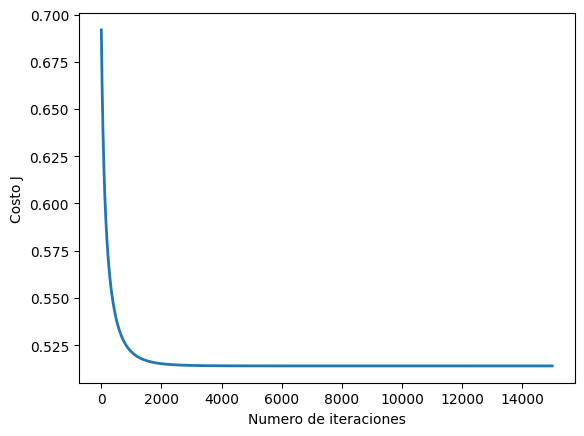

In [28]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 15000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(10)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# verificacion de efectiviadad del modelo con los primeros y ultimos 2 valores del data set de Prueba
X_array = [1 , 126. ,   0.54 , 4.39  ,21.13  , 1.  ,  45. ,   25.99 ,  0. ,   25.]
#X_array = [1 ,  162,     7.4,    8.55 , 24.65 ,  1 ,   64  ,  25.71  , 5.86 , 58]

prueba = sigmoid(np.dot(X_array, theta))

print(f"probabilidad de que tenga enfermedad cardio vascular (usando el descenso por el gradiente):{prueba}")